# Machine learning in chemistry*

```{admonition} Learning outcomes
After working through this topic, you should be able to:

1. explain the difference between rule-based programming and machine learning
2. identify observations, features and the target variable in a chemical dataset
3. split data into training and test sets
4. train and use a simple classification model
5. evaluate the model using test data, accuracy and a confusion matrix
6. explain overfitting, data leakage and important limitations of a model
```

In ordinary programs, we specify the rules that the computer should follow. In machine learning, we instead provide examples and allow an algorithm to learn patterns that can be applied to new data.

```{admonition} Machine learning
Machine learning refers to methods in which an algorithm learns patterns from examples and uses those patterns to make predictions for new observations.
```

Machine learning can be used in chemistry to classify spectra, predict properties from molecular descriptors, detect unusual process measurements, interpret images and chromatograms, and model relationships involving many variables.

A machine-learning model is not the same thing as a generative AI system such as ChatGPT. The model in this chapter learns a narrowly defined relationship in a small tabular dataset. A language model is trained on very large collections of data and generates sequences such as text. Both depend on data and statistical patterns, but their tasks, architectures and failure modes are very different.

```{admonition} Why is this chapter marked with an asterisk?
Machine learning builds on data handling, statistics and model evaluation. The purpose here is not to learn many algorithms, but to understand a basic workflow and learn to ask critical questions about a model.
```

## Case: classifying flame-emission measurements

Sodium, lithium and potassium ions have strong characteristic emission lines in different spectral regions. We use a small **synthetic teaching dataset** containing signal intensities near 589, 671 and 766 nm. The task is to classify each observation as `Na`, `Li` or `K`.

The dataset is deliberately simplified. It does not represent a fully validated analytical instrument; it mimics a situation in which different ions produce strong signals in different spectral regions.

In [1]:
import pandas as pd

data = pd.read_csv("data/flame_emission.csv")
print(data.head())
print(data.shape)
print(data["ion"].value_counts())

  sample_id  emission_589_nm  emission_671_nm  emission_766_nm ion
0     Na_01            91.37            14.86             9.71  Na
1     Na_02            89.16             8.68            14.60  Na
2     Na_03            85.72            16.30             9.55  Na
3     Na_04            85.25            13.61            14.07  Na
4     Na_05            88.06             9.16            10.32  Na
(60, 5)
ion
Na    20
Li    20
K     20
Name: count, dtype: int64


Each row is one sample measurement.

```{admonition} Features and target variable
**Features** are the variables the model is allowed to use as information. The **target variable** is the value or class that the model is trained to predict. Here, the emission intensities are features and `ion` is the target.
```

## Step 1: Explore the data

Before fitting a model, inspect the dataset.

In [2]:
data.info()
print(data.isna().sum())
print(data.groupby("ion").mean(numeric_only=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        60 non-null     object 
 1   emission_589_nm  60 non-null     float64
 2   emission_671_nm  60 non-null     float64
 3   emission_766_nm  60 non-null     float64
 4   ion              60 non-null     object 
dtypes: float64(3), object(2)
memory usage: 2.5+ KB
sample_id          0
emission_589_nm    0
emission_671_nm    0
emission_766_nm    0
ion                0
dtype: int64
     emission_589_nm  emission_671_nm  emission_766_nm
ion                                                   
K            12.0645          14.0945           90.064
Li           14.0645          86.0945           11.064
Na           88.0645          13.0945           12.064


Useful questions include:

- Are there missing values?
- Are the classes represented by similar numbers of observations?
- Are units and measurement conditions comparable?
- Is any proposed feature derived directly from the target?
- Are the observations genuinely independent?

We can also visualise two features before using a model:

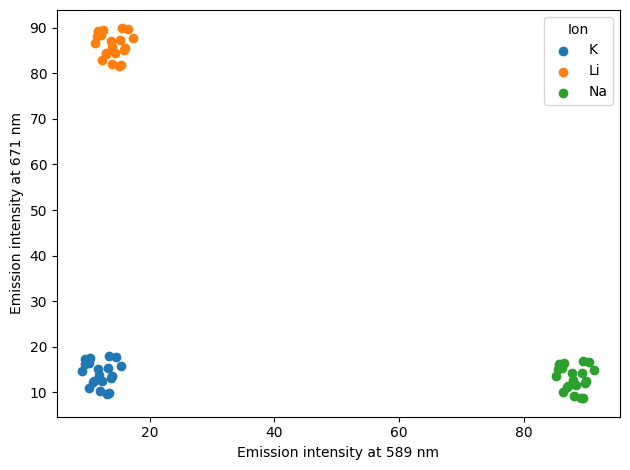

In [3]:
import matplotlib.pyplot as plt

for ion, group in data.groupby("ion"):
    plt.scatter(group["emission_589_nm"], group["emission_671_nm"], label=ion)

plt.xlabel("Emission intensity at 589 nm")
plt.ylabel("Emission intensity at 671 nm")
plt.legend(title="Ion")
plt.tight_layout()
plt.show()

The classes are already well separated in this simplified dataset. That is useful pedagogically: we can understand what the model is learning. It also illustrates a broader principle — if a problem is simple and chemically interpretable, we do not gain anything merely by choosing a more complicated algorithm.

## Step 2: Choose features and target

We use the three emission intensities as features and the ion identity as the target.

In [4]:
features = data[[
    "emission_589_nm",
    "emission_671_nm",
    "emission_766_nm",
]]
labels = data["ion"]

We deliberately do **not** use `sample_id` as a feature. The ID identifies a row but has no intended chemical relationship to the ion. Worse, the IDs in this dataset contain strings such as `Na_01` and `Li_01`; if encoded numerically, they could reveal the correct answer directly.

```{admonition} Data leakage
Data leakage occurs when information that would not legitimately be available when predicting a new observation enters the model-training process. Leakage can make model performance look unrealistically good.
```

## Step 3: Split into training and test sets

We need to evaluate the model on observations that were not used to fit it.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels,
)

- `test_size=0.30` places 30% of the observations in the test set.
- `random_state=42` makes this particular random split reproducible.
- `stratify=labels` preserves approximately the same class proportions in the training and test sets.

```{admonition} Training and test data
The training set is used to learn the model parameters. The test set is held back and used for a more independent evaluation of performance on unseen observations.
```

If we repeatedly alter a model because it performs poorly on the same test set, the test set begins to influence model development. In a larger project, model selection is therefore usually separated from the final evaluation using validation data or cross-validation.

## Step 4: Establish a baseline

Before celebrating a model score, ask what a trivial strategy would achieve. One baseline is always predicting the most common class.

In [6]:
from sklearn.metrics import accuracy_score

most_common_class = y_train.mode()[0]
baseline_predictions = [most_common_class] * len(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Baseline accuracy: 0.333


For a balanced three-class dataset, this baseline will usually be close to one third. A model that cannot outperform an appropriate simple baseline is not useful merely because it has been labelled machine learning.

## Step 5: Train a decision tree

A decision tree classifies observations using a sequence of threshold conditions. It is a good teaching model because the learned rules can be visualised.

In [7]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

During training, the algorithm chooses thresholds that separate the training classes. `max_depth=3` restricts the complexity of the tree. This is useful because an unrestricted tree can continue splitting until it models details that are specific to the training set.

## Step 6: Evaluate the model

Now we predict the held-out test observations.

In [8]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Test accuracy: {accuracy:.3f}")

Test accuracy: 1.000


Accuracy is the fraction of test observations classified correctly. It is easy to understand, but can be misleading for highly imbalanced classes. A model that always predicts a dominant class may then have high accuracy while being useless for the rare class.

A **confusion matrix** shows which classes are confused with one another.

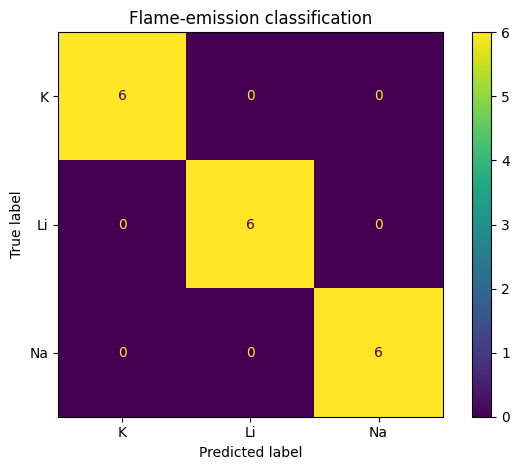

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("Flame-emission classification")
plt.tight_layout()
plt.show()

Rows represent the true classes and columns the predicted classes. Correct classifications lie on the diagonal.

You can run the full workflow and visualise the tree in the browser editor below.

<iframe src="../../basthon/?from=examples/machine_learning_flame_emission.py" width="100%" height="820" frameborder="0" title="Interactive Python editor for classifying flame-emission data" loading="lazy" allowfullscreen></iframe>

## What has the model learned?

We can visualise the decision tree.

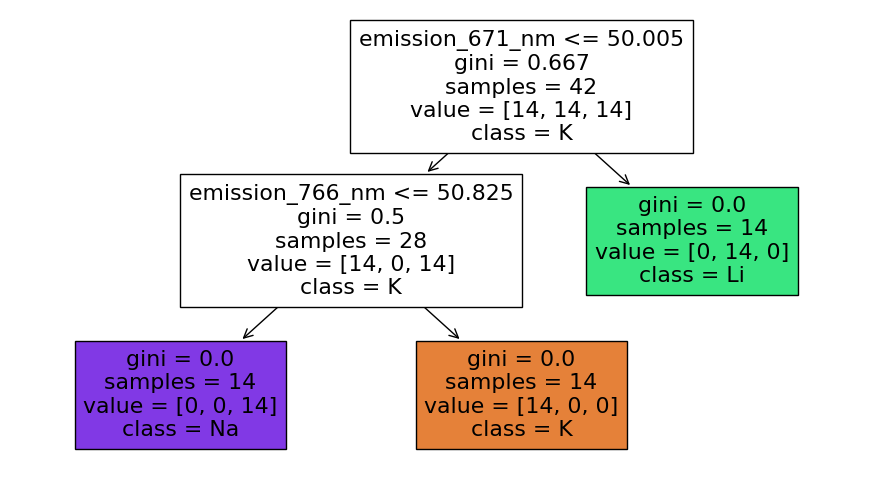

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))
plot_tree(
    model,
    feature_names=features.columns,
    class_names=model.classes_,
    filled=True,
)
plt.show()

The tree uses numerical thresholds on the emission intensities. We should compare these rules with the chemistry. If a sodium sample is distinguished by strong signal near 589 nm, that is chemically interpretable.

Interpretability does not automatically prove causality or validity, but it provides an opportunity to detect implausible behaviour. A model that classified ions using an accidental sample-number pattern instead of spectral information might still score well while being chemically meaningless.

## Overfitting

```{admonition} Overfitting
A model is overfit when it learns details or noise specific to the training data rather than patterns that generalise to new data.
```

One warning sign is a large gap between training and test performance.

In [11]:
training_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, predictions)

print(f"Training accuracy: {training_accuracy:.3f}")
print(f"Test accuracy:     {test_accuracy:.3f}")

Training accuracy: 1.000
Test accuracy:     1.000


Because this teaching dataset is deliberately easy, both scores may be very high. In real chemical data, performance differences are often larger. Restricting model complexity, collecting more representative data and using validation procedures can help, but no statistical technique can compensate for a dataset that does not represent the intended application.

## Data leakage in chemical workflows

Leakage can be subtle. Examples include:

- including a sample identifier that encodes the class;
- calculating a preprocessing transformation using the full dataset before splitting into training and test sets;
- having replicate spectra from the same physical sample in both training and test sets when the intended use is prediction for entirely new samples;
- including a feature measured after the outcome is already known;
- selecting variables by looking at performance on the final test set.

The third example is especially important in chemistry. If ten spectra from one sample are nearly identical, randomly splitting spectra can make the test set look independent even though almost the same physical sample appears in training. The correct unit for splitting should reflect the **scientific unit that needs to generalise**.

## Limitations of this example

Our small synthetic dataset is useful for learning the workflow, but not for claiming that we have built a deployable flame-test classifier. Important limitations include:

- the signals are synthetic and deliberately well separated;
- there are only 60 observations;
- measurement conditions do not vary realistically;
- mixtures and interfering species are absent;
- instrument drift and calibration transfer are absent;
- the test data come from the same synthetic data-generating process as the training data.

A model intended for real analytical use would need representative experimental data, an appropriate validation design, documented performance metrics and testing under conditions that resemble its intended use.

## A general machine-learning workflow for chemistry

1. **Define the scientific prediction task.** What is one observation, and what should generalise?
2. **Inspect and understand the data.** Units, missing values, measurement design, class balance.
3. **Separate features from the target.** Exclude identifiers and leaked information.
4. **Reserve independent data for evaluation.** Split at the scientifically appropriate level.
5. **Establish a simple baseline.**
6. **Fit a model no more complicated than necessary.**
7. **Evaluate on unseen data with suitable metrics.**
8. **Inspect errors and compare model behaviour with chemistry.**
9. **Document limitations and domain of applicability.**

Machine learning can reveal useful patterns, but a numerical score does not replace chemical understanding or experimental validation.

## Exercises

```{admonition} Exercise 5.1 — rules versus learning
:class: tip
Write a simple rule-based classifier that predicts `Na`, `Li` or `K` from whichever of the three emission intensities is largest. Compare its test accuracy with the decision tree. What does this tell you about whether machine learning is necessary for this simplified dataset?
```

```{admonition} Exercise 5.2 — identify the variables
:class: tip
Read `data/flame_emission.csv`. Identify the observations, features, target variable and columns that should not be used for training.
```

```{admonition} Exercise 5.3 — train/test split
:class: tip
Repeat `train_test_split` with several `random_state` values. How much does test accuracy vary? Why is performance from one small test split uncertain?
```

```{admonition} Exercise 5.4 — baseline
:class: tip
Calculate the accuracy of always predicting the most common training class. Explain why every predictive model should be compared with an appropriate baseline.
```

```{admonition} Exercise 5.5 — model complexity
:class: tip
Train decision trees with `max_depth` equal to 1, 2, 3 and `None`. Compare training and test accuracy. Which tree would you choose, and why?
```

```{admonition} Exercise 5.6 — confusion matrix
:class: tip
Inspect the confusion matrix. If errors occur, which ions are confused? Relate those errors to the emission intensities in the corresponding observations.
```

```{admonition} Exercise 5.7 — leakage
:class: tip
Explain why `sample_id` would be a dangerous feature in this dataset. Construct another hypothetical example of leakage from a chemical experiment.
```

```{admonition} Exercise 5.8 — realistic validation
:class: tip
Imagine that each physical solution is measured ten times. Should the ten replicate spectra be randomly split between training and test data if the intended application is classification of entirely new solutions? Propose a better split and explain why.
```

```{admonition} Exercise 5.9 — domain of applicability
:class: tip
The model has only seen pure Na, Li and K samples. What might happen if it receives a mixture, a spectrum dominated by calcium, or a measurement recorded on a different instrument? Explain why a classifier generally still returns a class even when none of its known classes is appropriate.
```